In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bayesflow as bf

from numba import njit, prange

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## DDM simulator with regressed parameterization

In [4]:
@njit
def simulate_ddm_trial(
    v: float,
    a: float,
    tau: float,
    s_v: float,
    s_tau: float,
    decay: float = 0.0,
    z: float = 0.0,
    sigma: float = 1.0,
    dt: float = 0.001,
    max_steps: int = 10000,
    log_transform: bool = True,
):

    if log_transform:
        a = np.exp(a)
        tau = np.exp(tau)
        # s_v = np.exp(s_v)

    v_i = np.random.normal(v, s_v)

    tau_i = tau + np.random.uniform(-s_tau * tau, s_tau * tau)

    # initialize
    a0 = a if a > 1e-6 else 1e-6
    d  = decay if decay > 0.0 else 0.0

    x = z * a0
    t = tau_i

    for _ in range(max_steps):
        t += dt
        bound = a0 * np.exp(-d * t)
        if bound < 1e-3:
            bound = 1e-3
        x += v_i * dt + sigma * np.sqrt(dt) * np.random.normal()
        if x >= bound:
            return np.array([t, 1.0], dtype=np.float32)
        if x <= -bound:
            return np.array([t, 0.0], dtype=np.float32)
    # No decision within max_steps
    return np.array([-1.0, -1.0], dtype=np.float32)

In [5]:
@njit
def simulate_ddm_dataset_regressed(
    x: np.ndarray,                 # shape (num_obs,)
    beta_v0: float,
    beta_v1: float,
    beta_a0: float,
    beta_a1: float,
    tau: float,
    s_v: float,
    s_tau: float,
    decay: float = 0.0,
    z: float = 0.0,
    sigma: float = 1.0,
    dt: float = 0.001,
    max_steps: int = 10000,
    log_transform: bool = True,
) -> np.ndarray:
    """
    Returns array of shape (num_obs, 2): [rt, choice] per trial.
    Uses *regression coefficients* as the inferred parameters (intercepts/slopes).
    """
    n = x.shape[0]
    out = np.empty((n, 2), dtype=np.float32)

    for i in range(n):
        v_i = beta_v0 + beta_v1 * x[i]
        a_i = beta_a0 + beta_a1 * x[i]

        out[i, :] = simulate_ddm_trial(
            v=v_i,
            a=a_i,
            tau=tau,
            s_v=s_v,
            s_tau=s_tau,
            decay=decay,
            z=z,
            sigma=sigma,
            dt=dt,
            max_steps=max_steps,
            log_transform=log_transform,
        )

    return out

In [57]:
class RegressedDDMSimulator:
    """
    Batch simulator for a DDM where drift and non-decision time
    are regressed on a known trial-level covariate x.
    """

    def __init__(
        self,
        x_sampler,
        prior_sampler,
        log_transform: bool = True,
    ):
        """
        Parameters
        ----------
        x_sampler : callable
            Function x_sampler(num_obs) -> array (num_obs,)
        prior_sampler : callable
            Function prior_sampler() -> dict of global parameters
        log_transform : bool
            Passed to simulate_ddm_trial
        """
        self.x_sampler = x_sampler
        self.prior_sampler = prior_sampler
        self.log_transform = log_transform

    def sample(
        self,
        batch_size: int | tuple,
        num_obs: int = 500,
    ):
        """
        Sample a batch of simulated datasets.

        Parameters
        ----------
        batch_size : int or (int, int)
            Number of datasets, or range to sample from.
        num_obs : int
            Number of trials per dataset.

        Returns
        -------
        list[dict]
            Each element contains x, rt, choice, params.
        """
        # Resolve batch size
        if isinstance(batch_size, tuple):
            batch_size = batch_size[0]

        rts = np.zeros((batch_size, num_obs))
        choices = np.zeros((batch_size, num_obs))
        batch_params = np.zeros((batch_size, 7))

        for i in range(batch_size):
            # 1) Sample regressor
            x = self.x_sampler(num_obs).astype(np.float32)

            # 2) Sample global parameters
            params = self.prior_sampler()

            # 3) Simulate dataset
            sim = simulate_ddm_dataset_regressed(
                x=x,
                beta_v0=params[0],
                beta_v1=params[1],
                beta_a0=params[2],
                beta_a1=params[3],
                a=params[4],
                s_v=params[5],
                s_tau=params[6],
                log_transform=self.log_transform,
            )
            rts[i] = sim[:, 0]
            choices[i] = sim[:, 1]
            batch_params[i] = params

        batch = {"rts": rts, "choices": choices, "params": batch_params}

        return batch

In [58]:
def x_sampler(num_obs):
    # Example: signed stimulus strength
    return np.random.uniform(-1.0, 1.0, size=num_obs)

In [59]:
def priors():
    beta_v0 = np.random.normal(0.0, 0.5)
    beta_v1 = np.random.normal(1.0, 0.5)
    beta_tau0 = np.random.normal(np.log(0.3), 0.2)
    beta_tau1 = np.random.normal(0.0, 0.2)
    a = np.random.normal(np.log(1.5), 0.2)
    s_v = np.random.uniform(0.0, 0.5)
    s_tau = np.random.uniform(0.0, 0.3)
    return np.array([beta_v0, beta_v1, beta_tau0, beta_tau1, a, s_v, s_tau])

In [60]:
num_obs = 500
simulator = RegressedDDMSimulator(x_sampler=x_sampler, prior_sampler=priors)

In [61]:
samples = simulator.sample(batch_size=2)

In [64]:
for k, v in samples.items():
    print(k, v.shape)

rts (2, 500)
choices (2, 500)
params (2, 7)


In [82]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .rename("params", "inference_variables")
    .expand_dims(["rts", "choices"], axis=-1)
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [83]:
adapted_sims = adapter(simulator.sample(batch_size=2))

In [84]:
for k, v in adapted_sims.items():
    print(k, v.shape)

inference_variables (2, 7)
summary_variables (2, 500, 2)


In [93]:
batch_size = 32
epochs = 50
summary_network = bf.networks.SetTransformer(summary_dim=16, seed_dim=128)
inference_network = bf.networks.FlowMatching()

In [94]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_regressed.ckpt",
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [96]:
train_set = workflow.simulate(5000)
val_set = workflow.simulate(300)

In [98]:
history = workflow.fit_offline(
    train_set,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=val_set
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 4.3117 - val_loss: 1.9493
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 2.0969 - val_loss: 1.6900
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.6901 - val_loss: 1.5579
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.4641 - val_loss: 1.4510
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.4299 - val_loss: 1.3792
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.3848 - val_loss: 1.3695
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 1.3585 - val_loss: 1.2993
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.3252 - val_loss: 1.2935
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.3221 - val_loss: 1.2626
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.3276 - val_loss: 1.2373
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.2898 - val_loss: 1.2682
Epoch 12/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_regressed.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [89]:
param_names = [
    r"$\beta_{v,0}$",
    r"$\beta_{v,1}$",
    r"$\beta_{\tau,0}$",
    r"$\beta_{\tau,1}$",
    r"$a$",
    r"$s_v$",
    r"$s_\tau$"
]

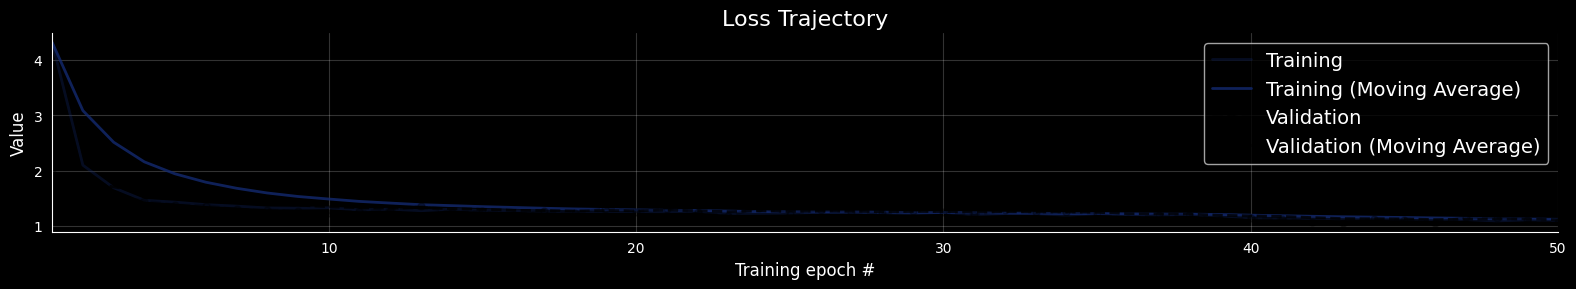

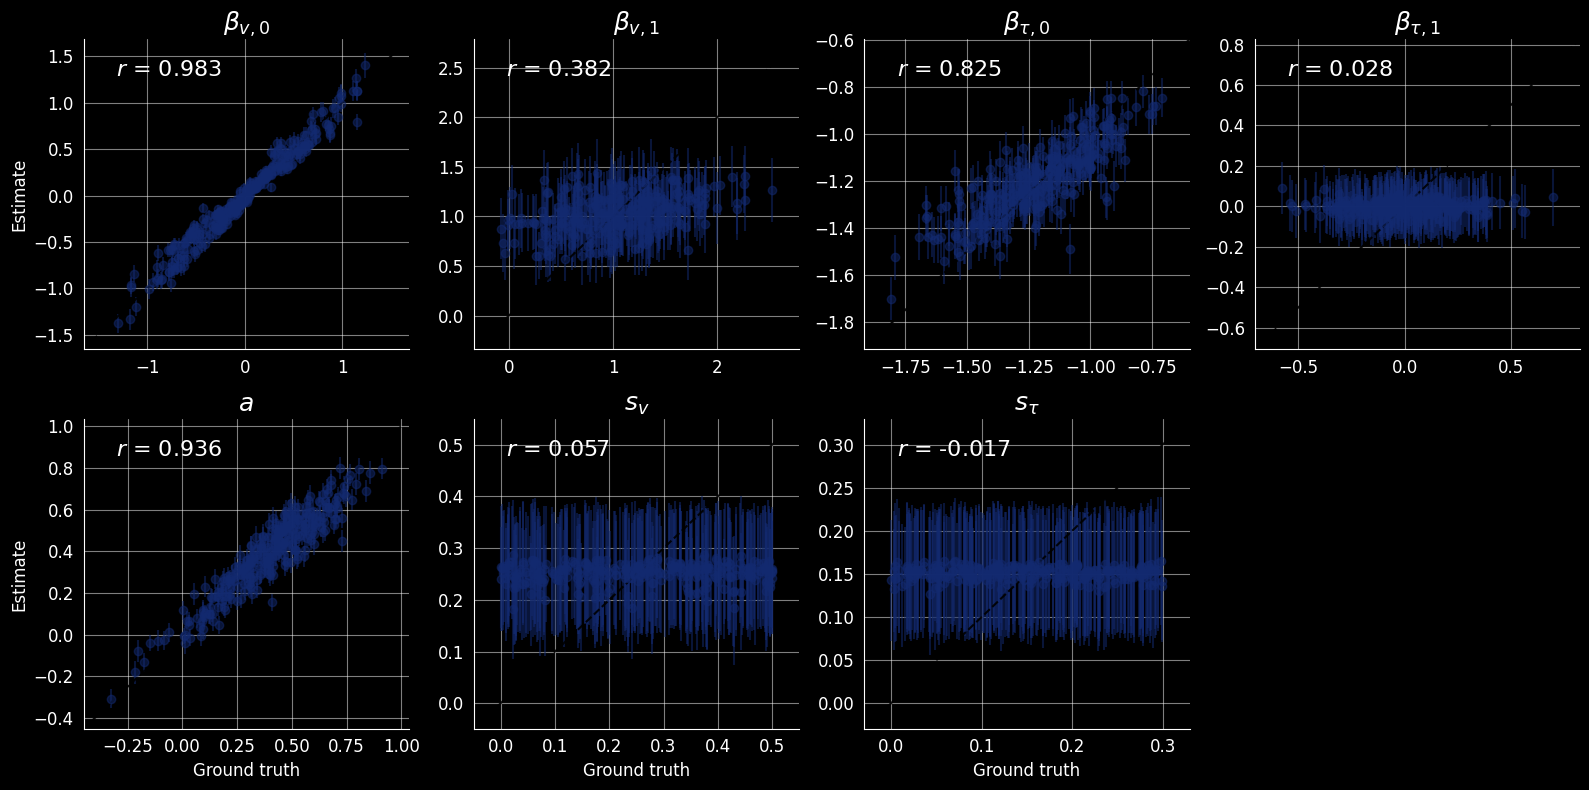

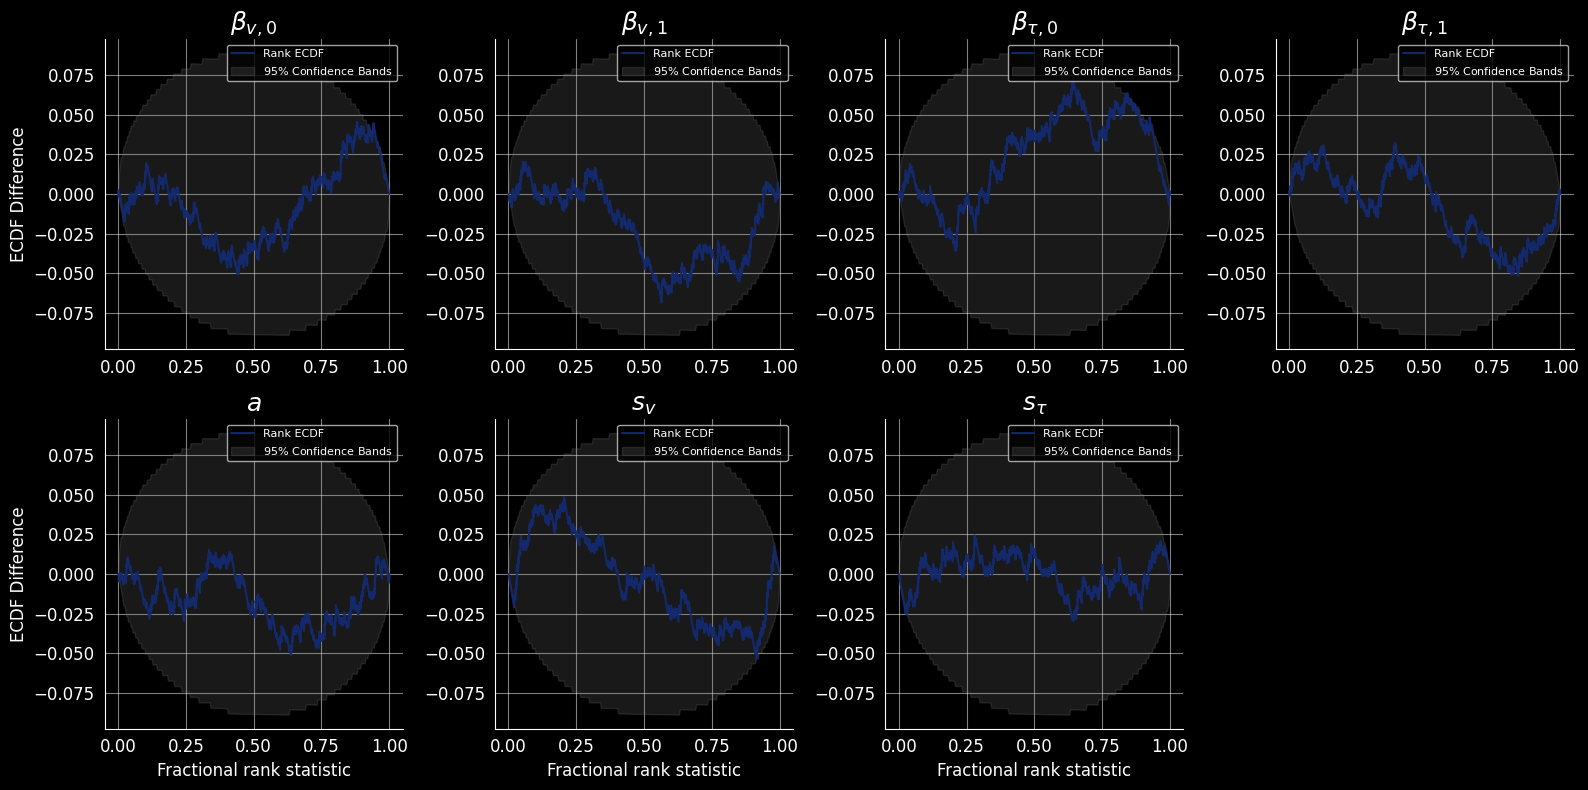

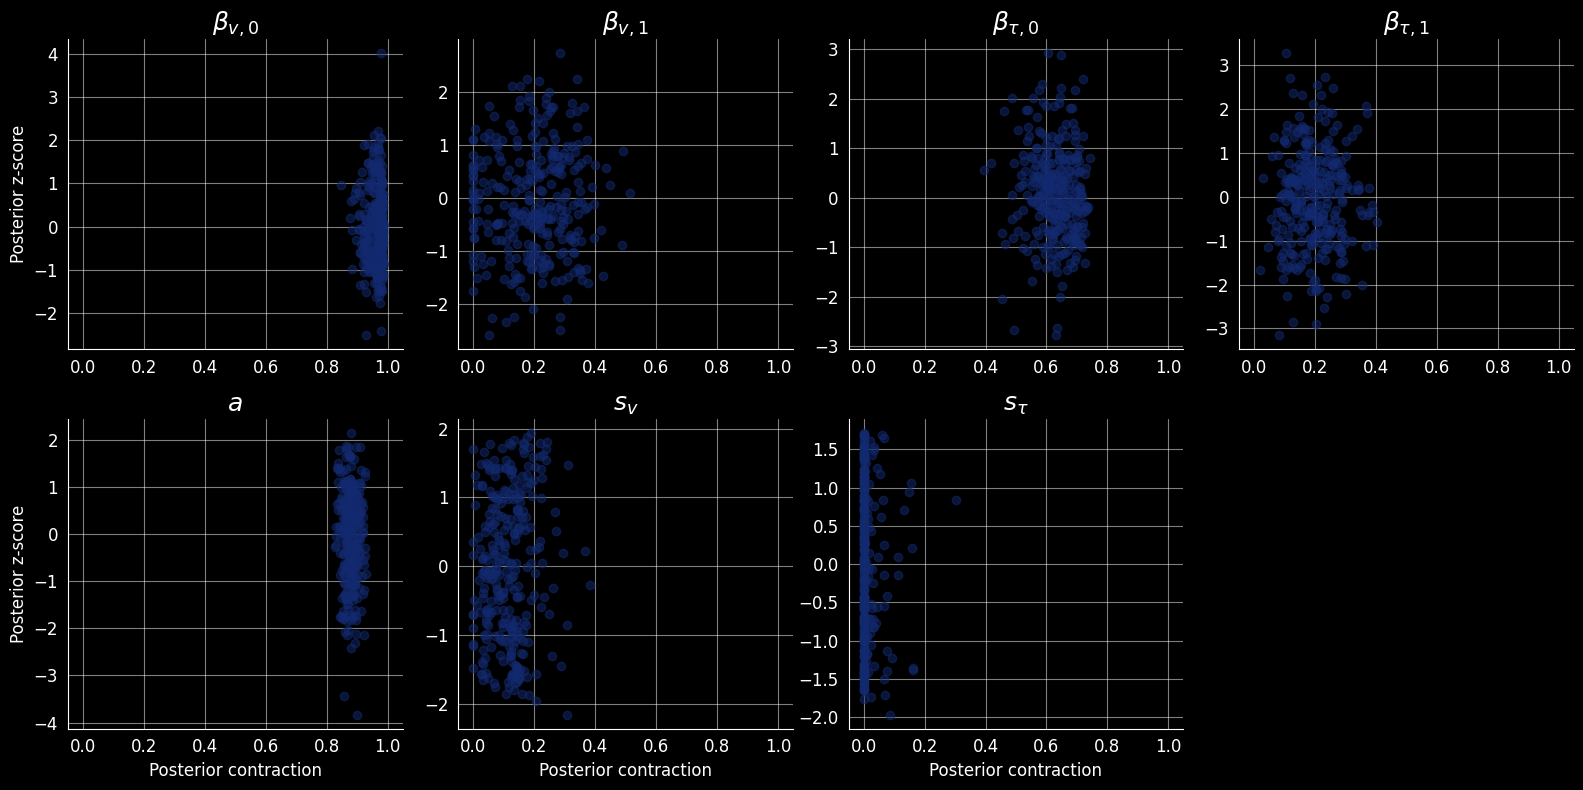

In [101]:
fig = workflow.plot_default_diagnostics(
    test_data=val_set,
    variable_names=param_names,
    loss_kwargs={"figsize": (16, 4), "label_fontsize": 12},
    recovery_kwargs={"figsize": (16, 8), "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": (16, 8), "legend_fontsize": 8, "difference": True, "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": (16, 8), "label_fontsize": 12}
)